# Iterated Fractal Systems

[Moreno Marzolla](https://www.moreno.marzolla.name)

Written in March 2026.

Last modified June 2026.

---

An _affine transformation_ is a tuple $(a, b, c, d, e, f)$ that maps a point $(x, y)$ to the new coordinates $(ax + by + e, cx + dy + f)$. This can be expressed in matrix form as:

$$
f(x,y) = \begin{pmatrix}
a & b \\
c & d 
\end{pmatrix}
\begin{pmatrix}
x \\
y
\end{pmatrix}
+
\begin{pmatrix}
e \\
f
\end{pmatrix}
$$

In [156]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import itertools as it

In [157]:
def affine(p, transformation):
    """
    Transform point `p=(x,y)` according to affine `transformation=(a,b,c,d,e,f)`.
    Return the transformed point `p'=(x',y')`.    
    """
    a, b, c, d, e, f = transformation
    x, y = p
    return (a*x + b*y + e), (c*x + d*y + f)

An _Iterated Fractal System_ (IFS) can be draw through an iterative procedure, as follows. We start with a matrix $M \in \mathbb{R}^{P \times 6}$ with $P$ rows and six columns; each row contains the parameters of one affine transformation:

\begin{equation*}
M = \left(\begin{matrix}
a_0 & b_0 & c_0 & d_0 & e_0 & f_0 \\
a_1 & b_1 & c_1 & d_1 & e_1 & f_1 \\
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots \\
a_{P-1} & b_{P-1} & c_{P-1} & d_{P-1} & e_{P-1} & f_{P-1}
\end{matrix}\right)
\end{equation*}

Start with a random point $p_0$ in the unitary square; at each step apply a randomly chosen transformation to the last drawn point $p_k$ to get a new point $p_{k+1}$, and repeat. At the end of this process, we get a sequence of $n$ points $p_0, p_1, \ldots, p_{n-1}$ that represent the orbit of $p_0$ under repeated application of a random affine transformation. Draw all points, and then start all over again with a new random initial point. (there are variants of IFS that allow the user to specify the probability of each rule).

In essence, an IFS is made of the superposition of the orbits of $n$ randomly chosen initial points.

In [158]:
def apply_random_rule(p, rule):
    """
    Applies a random transformation from `rule` to point `p`.
    `rule` must be a rectangular matrix with six columns; each row
    is a transformation.
    """
    n = len(rule)
    ruleno = np.random.choice(n)
    return affine(p, rule[ruleno])

def iterate(f, p):
    """
    Generates the infinite orbit of point `p` under repeated application of function `f`.
    """
    while True:
        yield(p)
        p = f(p)

def orbit(f, p0, n):
    """
    Return the first `n` points of the orbit of `p0` under repeated application of function `f`.
    In other words, return the sequence p0, f(p0), f(f(p0)), ...
    """
    return list(it.islice(iterate(f, p0), n))

def IFS(rule, norbits=100, points_per_orbit=1000):
    """
    Draw an IFS; generate `norbits` random starting points ("seeds"), and for each seed, 
    generate an orbit of `points_per_orbit` points.
    """
    for _ in range(norbits):
        p0 = np.random.rand(2)
        points = orbit(lambda p: apply_random_rule(p, rule), p0, points_per_orbit)
        x, y = zip(*points)
        plt.plot(list(x), list(y), '.k', ms=0.1)
    #plt.show()

Let us try some rule.

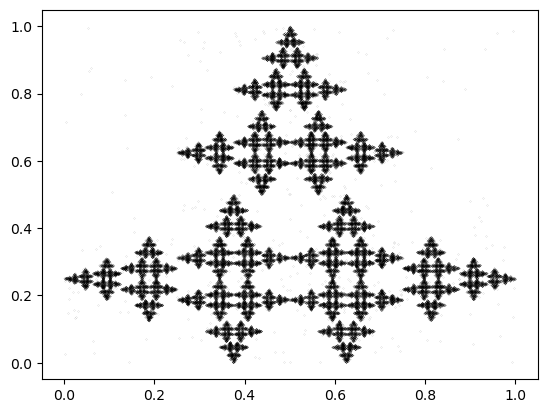

In [159]:
rule1 = [[ 0.0000, -0.5000,  0.5000,  0.0000,  0.5000,  0.0000],
         [ 0.0000,  0.5000, -0.5000,  0.0000,  0.5000,  0.5000],
         [ 0.5000,  0.0000,  0.0000,  0.5000,  0.2500,  0.5000]]

IFS(rule1)

It is difficult to understand what an affine transformation does by just looking at a table of numbers; therefore, we define a function `show_transformation(rules)` that displays `rules` in graphical form. The function scans each row of `rules`, and then plots the transformed unitary square using each transformation on `rules`.

In [160]:
def show_transformation(rules):
    """
    Display the transformation induced by `rules`;
    `rules` must be a matrix with six columns.
    """
    for r in rules:
        square = np.matrix([affine([0,0], r),
                            affine([0,1], r),
                            affine([1,1], r),
                            affine([1,0], r),
                            affine([0,0], r)])
        x, y = square[:, 0], square[:, 1]
        plt.fill(x, y, alpha=0.5)
        plt.plot(x, y)
        el = np.matrix([affine([0.1, 0.1], r),
                        affine([0.1, 0.9], r),
                        affine([0.9, 0.9], r)])
        plt.plot(el[:, 0], el[:,1], 'k')
    #plt.show()

As an example, let us have a look at the rule above.

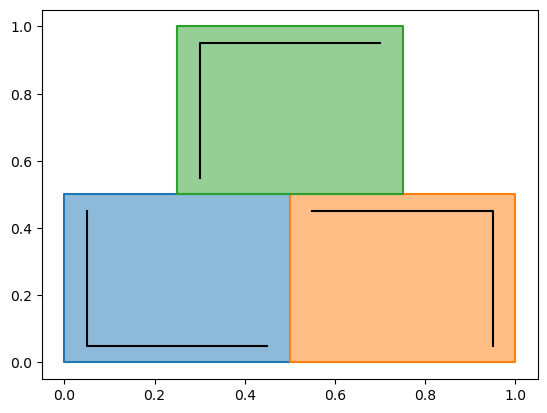

In [161]:
show_transformation(rule1)

The following matrices are suggested by Gary William Flake, "The Computational Beauty of Nature", chapter 7 _Affine Transformations_.

In [200]:
rule2 = [[ 0.7500,  0.0000,  0.0000,  0.7500,  0.1250,  0.1250],
         [ 0.5000, -0.5000,  0.5000,  0.5000,  0.5000,  0.0000],
         [ 0.2500,  0.0000,  0.0000,  0.2500,  0.0000,  0.7500],
         [ 0.2500,  0.0000,  0.0000,  0.2500,  0.7500,  0.7500],
         [ 0.2500,  0.0000,  0.0000,  0.2500,  0.0000,  0.0000],
         [ 0.2500,  0.0000,  0.0000,  0.2500,  0.7500,  0.0000]]

# Devil's staircase
rule3 = [[ 0.3333,  0.0000,  0.0000,  0.5000,  0.0000,  0.0000],
         [ 0.3333,  0.0000,  0.0000,  0.5000,  0.3333,  0.0000],
         [ 0.3333,  0.0000,  0.0000,  0.5000,  0.6667,  0.0000],
         [ 0.3333,  0.0000,  0.0000,  0.5000,  0.6667,  0.5000],
         [-0.3333,  0.0000,  0.0000, -0.5000,  0.6667,  0.5000],
         [-0.3333,  0.0000,  0.0000, -0.5000,  1.0000,  0.5000]]

rule4 = [[ 0.0000,  0.5770, -0.5770,  0.0000,  0.0951,  0.5893],
         [ 0.0000,  0.5770, -0.5770,  0.0000,  0.4413,  0.7893],
         [ 0.0000,  0.5770, -0.5770,  0.0000,  0.0952,  0.9893]]

rule5 = [[ 0.2500,  0.0000,  0.0000,  0.9000,  0.3750,  0.0000],
         [ 0.6500,  0.0000,  0.0000,  0.7500,  0.1750,  0.2500],
         [ 0.0000, -0.5000,  0.2500,  0.0000,  0.5000,  0.2000],
         [ 0.0000,  0.5000, -0.2500,  0.0000,  0.5000,  0.4500]]

# Tree
rule6 = [[ 0.1950, -0.4880,  0.3440,  0.4430,  0.4431,  0.2453],
         [ 0.4620,  0.4140, -0.2520,  0.3610,  0.2511,  0.5692],
         [-0.0580, -0.0700,  0.4530, -0.1110,  0.5976,  0.0969],
         [-0.0350,  0.0700, -0.4690, -0.0220,  0.4884,  0.5069],
         [-0.6370,  0.0000,  0.0000,  0.5010,  0.8562,  0.2513]]

# Grass
rule7 = [[ 0.3870,  0.4300,  0.4300, -0.3870,  0.2560,  0.5220],
         [ 0.4410, -0.0910, -0.0090, -0.3220,  0.4219,  0.5059],
         [-0.4680,  0.0200, -0.1130,  0.0150,  0.4000,  0.4000]]

# Grass 2
rule8 = [[ 0.5000,  0.0000,  0.0000,  0.7450,  0.2500,  0.0000],
         [ 0.2500, -0.2000,  0.1000,  0.3000,  0.2500,  0.5000],
         [ 0.2500,  0.2000, -0.1000,  0.3000,  0.5000,  0.4000],
         [ 0.2000,  0.0000,  0.0000,  0.3000,  0.4000,  0.5500]]

# Fern <https://en.wikipedia.org/wiki/Barnsley_fern>
rule9 = [[ 0.00,  0.00,  0.00, 0.16, 0.00, 0.00],
         [ 0.85,  0.04, -0.04, 0.85, 0.00, 1.60],
         [ 0.20, -0.26,  0.23, 0.22, 0.00, 1.60],
         [-0.15,  0.28,  0.26, 0.24, 0.00, 0.44]]

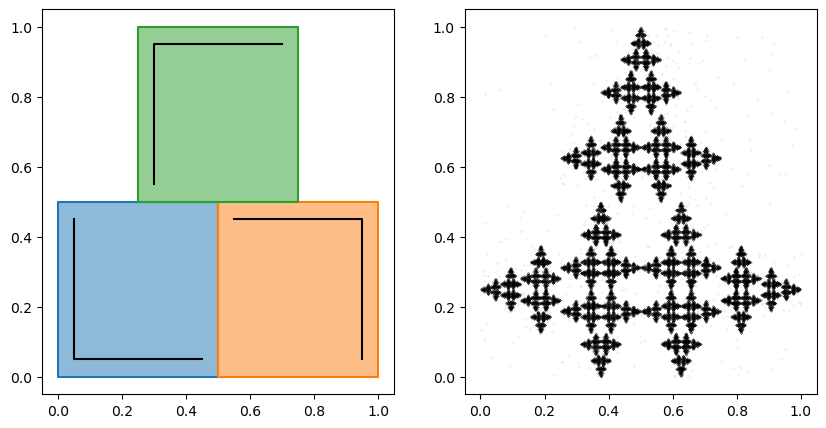

In [201]:
def draw_IFS_and_rule(rule, norbits=100, points_per_orbit=1000):
    plt.subplots(1, 2, figsize=(10,5))
    plt.subplot(1, 2, 1)    
    show_transformation(rule)
    plt.subplot(1, 2, 2)
    IFS(rule, norbits, points_per_orbit)
    plt.show()
    
draw_IFS_and_rule(rule1)

# References

- Gary William Flake, [The Computational Beauty of Nature: Computer Explorations of Fractals, Chaos, Complex Systems, and Adaptation](https://mitpress.mit.edu/9780262561273/the-computational-beauty-of-nature/), MIT Press, 2000, ISBN 978-0262561273